# Aula 8 · Avaliação de modelos de classificação
### Da acurácia à generalização com KNN
**Professor Daniel da Silva Souza** · Aprendizagem de Máquina

**Pergunta da aula:** um modelo que acerta todos os exemplos de treino é necessariamente bom?

Vamos carregar uma base real, separar os dados, treinar um KNN, medir seus acertos e observar como o número de vizinhos altera o comportamento do modelo. As figuras são produzidas pelo código deste notebook.

**Ao terminar, você deverá conseguir:**
- distinguir treino, validação e teste;
- calcular e interpretar a acurácia;
- identificar sinais de underfitting e overfitting;
- comparar valores de `k` e justificar uma escolha;
- avaliar uma configuração escolhida em dados reservados.

**Pré-requisitos:** variáveis, listas, `for`, DataFrames e noção inicial de classificação/KNN.

## Como usar na aula

1. Abra este `.ipynb` no **Google Colab**, Jupyter Notebook ou VS Code com suporte a notebooks.
2. Execute as células na ordem, de cima para baixo. No Colab/Jupyter, use **Shift + Enter**.
3. Antes de cada experimento, faça uma previsão; depois, confronte-a com a saída.
4. As seções **1 a 10** são a aula guiada. A **seção 11** contém a atividade para entregar **até a próxima aula**.
5. Salve uma cópia com seu nome. O gabarito é um arquivo separado destinado ao professor.

**Roteiro sugerido (aproximadamente 120 minutos de atividade, ajustável ao ritmo da turma):**

| Etapa | Seções | Tempo aproximado |
|---|---|---:|
| Conhecer os dados e medir acertos | 1–3 | 20 min |
| Separar dados e treinar o primeiro modelo | 4–5 | 25 min |
| Entender visualmente o ajuste | 6–7 | 30 min |
| Comparar k, escolher e avaliar | 8–9 | 30 min |
| Retomar ideias e orientar a entrega | 10–11 | 15 min |

As bases reais já acompanham o scikit-learn. **Não é necessário baixar CSV, criar conta em um repositório de dados ou acessar uma URL durante a execução.** A instalação das bibliotecas, caso necessária, exige internet. O notebook já contém as saídas da execução de referência.

Se faltar alguma biblioteca, descomente e execute a célula abaixo. Depois, reinicie o kernel se o ambiente solicitar.

In [10]:
# Execute somente se aparecer ModuleNotFoundError:
# %pip install numpy pandas matplotlib scikit-learn

## 1. Preparar o ambiente

Importamos as ferramentas uma única vez. `numpy` trabalha com arrays; `pandas`, com tabelas; `matplotlib`, com gráficos; e `scikit-learn`, com os modelos e a avaliação.

In [11]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from sklearn.datasets import load_breast_cancer, load_wine, make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 115,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.labelsize": 11,
    "font.size": 10, "axes.grid": False,
})
AZUL, LARANJA, VERDE = "#176B9A", "#D36B26", "#26806C"
print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__, "| pandas:", pd.__version__)

Python: 3.11.3
scikit-learn: 1.9.1
NumPy: 1.24.3 | pandas: 1.5.3


## 2. Conhecer a base de dados real

Usaremos **Breast Cancer Wisconsin (Diagnostic)**, disponibilizada no scikit-learn a partir do repositório UCI. Cada linha representa uma amostra descrita por medidas numéricas de características dos núcleos celulares em imagens.

| Elemento | Significado nesta aula |
|---|---|
| 569 linhas | Amostras disponíveis |
| 30 características | Medidas que entram no modelo, como raio e textura |
| `X` | Tabela com as 30 características |
| `y` | Classe conhecida de cada amostra |
| Classe `0` | Maligno |
| Classe `1` | Benigno |

O objetivo didático é prever a classe a partir das medidas. **Os números 0 e 1 são rótulos de categorias, não uma escala de gravidade.** O experimento é educacional, não um sistema de diagnóstico.

**Antes de executar:** qual coluna não pode entrar em `X`, pois revelaria a resposta?

In [12]:
base = load_breast_cancer(as_frame=True)
X = base.data.copy()
y = base.target.copy()
nomes_classes = {0: "Maligno", 1: "Benigno"}

dados = X.copy()
dados["classe"] = y
print(f"Amostras: {X.shape[0]} | Características: {X.shape[1]}")
print("Valores ausentes:", int(dados.isna().sum().sum()))
display(dados.head())
display(pd.DataFrame({"código": [0, 1], "classe": [nomes_classes[0], nomes_classes[1]]}))

Amostras: 569 | Características: 30
Valores ausentes: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,classe
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


,código,classe
0,0,Maligno
1,1,Benigno


### 2.1. Há a mesma quantidade de exemplos em cada classe?

Conte as classes antes de interpretar uma acurácia. Uma classe mais frequente pode tornar a tarefa aparentemente fácil para um modelo que sempre responde a mesma coisa.

,classe,quantidade,percentual
0,Maligno,212,37.3
1,Benigno,357,62.7


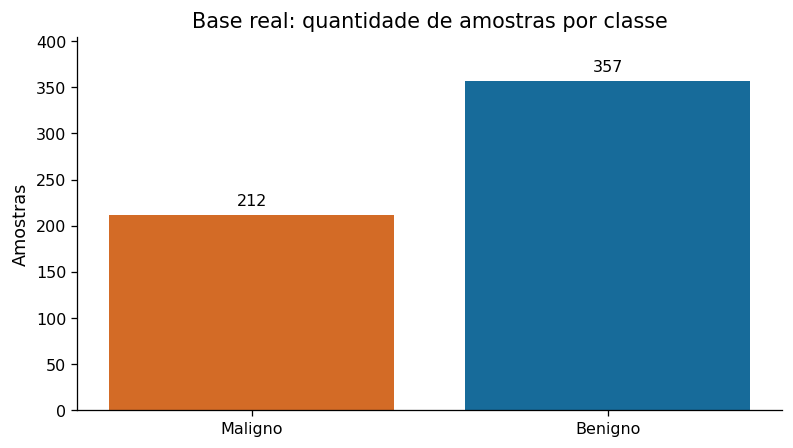

In [13]:
contagem = y.value_counts().sort_index()
distribuicao = pd.DataFrame({
    "classe": [nomes_classes[i] for i in contagem.index],
    "quantidade": contagem.values,
    "percentual": (contagem / len(y) * 100).round(1).values,
})
display(distribuicao)

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(distribuicao["classe"], distribuicao["quantidade"], color=[LARANJA, AZUL])
ax.bar_label(barras, padding=4)
ax.set(title="Base real: quantidade de amostras por classe", ylabel="Amostras", ylim=(0, 405))
plt.tight_layout()
plt.show()

## 3. O que a acurácia mede?

É a proporção de previsões corretas entre todas as previsões avaliadas:

$$\mathrm{Acurácia} = \frac{\text{número de acertos}}{\text{número de exemplos avaliados}}$$

**Exemplo:** acertar 4 de 5 classificações significa acurácia de $4/5 = 0{,}80 = 80\%$.

**Faça com os alunos:** compare os dois arrays abaixo e conte os acertos antes de executar.

In [14]:
reais_exemplo = np.array([0, 1, 1, 0, 1])
previstos_exemplo = np.array([0, 1, 0, 0, 1])
acertos_exemplo = reais_exemplo == previstos_exemplo

display(pd.DataFrame({
    "Real": reais_exemplo,
    "Previsto": previstos_exemplo,
    "Acertou?": acertos_exemplo,
}))
print(f"Conta manual: {acertos_exemplo.sum()}/{len(reais_exemplo)} = {acertos_exemplo.mean():.0%}")
print(f"accuracy_score: {accuracy_score(reais_exemplo, previstos_exemplo):.0%}")

,Real,Previsto,Acertou?
0,0,0,True
1,1,1,True
2,1,0,False
3,0,0,True
4,1,1,True


Conta manual: 4/5 = 80%
accuracy_score: 80%


### Acertar muito pode ser insuficiente

Imagine 100 clientes: 90 permanecem e 10 cancelam. Prever **“permanece” para todos** produz 90% de acurácia, mas não identifica nenhum dos 10 cancelamentos.

Por isso, compare com uma **referência simples (baseline)**: qual seria o resultado de sempre prever a classe mais frequente? Nesta aula, usaremos acurácia para aprender o processo de avaliação; ela não descreve sozinha todos os tipos de erro.

**Pergunta ao grupo:** um resultado de 88% seria bom nesse exemplo de clientes? Por quê?

## 4. Aprender, escolher e avaliar são etapas diferentes

**Generalizar** é usar o que foi aprendido para classificar exemplos que não participaram do ajuste do modelo.

| Conjunto | Para que serve? | Analogia com os estudos |
|---|---|---|
| Treino | Ajustar o modelo e a padronização | Exercícios estudados |
| Validação | Comparar configurações, como os valores de `k` | Simulado para orientar a preparação |
| Teste | Avaliar a configuração final escolhida | Prova final reservada |

O material de referência começa com treino/teste. Como aqui vamos **experimentar vários valores de `k`**, acrescentaremos a validação. Se escolhermos `k` pelo resultado do teste, ele deixa de ser uma avaliação independente da escolha.

Usaremos aproximadamente **60% para treino, 20% para validação e 20% para teste**:

1. Reserve 20% para teste. Sobram 80% para desenvolvimento (`X_dev`, `y_dev`).
2. Separe 25% desses 80% para validação: $0{,}25 \times 80\% = 20\%$ do total.

`random_state=42` torna a divisão reproduzível; **42 não é um valor especial nem melhora o modelo**. `stratify` preserva aproximadamente as proporções das classes, respeitando o arredondamento das quantidades.

,Conjunto,Quantidade,% do total
0,Treino,341,59.9
1,Validação,114,20.0
2,Teste reservado,114,20.0


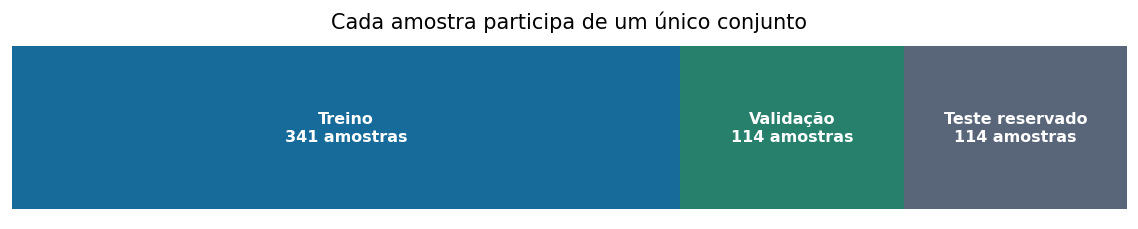

In [15]:
# 1) Guardar o teste final.
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2) Separar treino e validação dentro do conjunto de desenvolvimento.
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=42, stratify=y_dev
)

resumo_divisao = pd.DataFrame({
    "Conjunto": ["Treino", "Validação", "Teste reservado"],
    "Quantidade": [len(y_train), len(y_val), len(y_test)],
})
resumo_divisao["% do total"] = (resumo_divisao["Quantidade"] / len(y) * 100).round(1)
display(resumo_divisao)

# Conferir que nenhuma linha aparece em dois conjuntos.
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_val) + len(X_test) == len(X)

fig, ax = plt.subplots(figsize=(10, 2.1))
inicio = 0
for nome, qtd, cor in zip(resumo_divisao["Conjunto"], resumo_divisao["Quantidade"], [AZUL, VERDE, "#596579"]):
    ax.barh(0, qtd, left=inicio, color=cor, height=0.55)
    ax.text(inicio + qtd / 2, 0, f"{nome}\n{qtd} amostras", ha="center", va="center", color="white", fontweight="bold")
    inicio += qtd
ax.set_xlim(0, len(y))
ax.set_title("Cada amostra participa de um único conjunto")
ax.axis("off")
plt.tight_layout()
plt.show()

**Conferência esperada:** 341 amostras de treino, 114 de validação e 114 de teste. O teste está reservado: não vamos calcular seu desempenho durante a escolha de `k`.

### 4.1. Criar a referência simples

O `DummyClassifier` abaixo aprende apenas qual é a classe mais frequente **no treino**. Ele sempre prevê essa classe, independentemente das características.

In [16]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
acuracia_baseline = baseline.score(X_val, y_val)
print(f"Baseline na validação: {acuracia_baseline:.2%}")

Baseline na validação: 62.28%


## 5. Treinar nosso primeiro KNN

O KNN procura os `k` exemplos de treino mais próximos de uma nova amostra e faz uma votação. Com `k=5`, cada um dos cinco vizinhos tem um voto. Nesta aula, todos os votos têm o mesmo peso (`weights="uniform"`).

### 5.1. Por que padronizar as características?

O KNN usa distâncias. Uma medida com valores na casa dos milhares pode dominar outra com valores próximos de 0,1 apenas pela escala. O `StandardScaler` coloca as características em escalas comparáveis:

$$z = \frac{x-\mu_{\mathrm{treino}}}{\sigma_{\mathrm{treino}}}$$

Não é preciso fazer essa conta à mão. Precisamos lembrar que **a média e o desvio são calculados no treino** e reutilizados nos outros conjuntos.

Usaremos uma `Pipeline`, uma sequência com dois passos:
1. `StandardScaler()`: aprende e aplica a padronização;
2. `KNeighborsClassifier(...)`: usa os dados padronizados para classificar.

Assim, `fit(X_train, y_train)` ajusta os passos com o treino. `predict` e `score` aplicam a transformação já aprendida aos dados recebidos. **Não faça `fit` na validação ou no teste.**

In [17]:
modelo_inicial = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5, weights="uniform")
)
modelo_inicial.fit(X_train, y_train)
previsoes_val = modelo_inicial.predict(X_val)

print(f"Acurácia no treino: {modelo_inicial.score(X_train, y_train):.2%}")
print(f"Acurácia na validação: {accuracy_score(y_val, previsoes_val):.2%}")
print(f"score na validação: {modelo_inicial.score(X_val, y_val):.2%}")
print(f"Baseline na validação: {acuracia_baseline:.2%}")

Acurácia no treino: 97.36%
Acurácia na validação: 95.61%
score na validação: 95.61%
Baseline na validação: 62.28%


### 5.2. Conferir as previsões, linha por linha

Para este classificador, `.score(X, y)` devolve a acurácia. É a mesma ideia de comparar `.predict(X)` com os rótulos reais usando `accuracy_score`.

**Observe:** acertar os exemplos usados no ajuste é diferente de acertar os exemplos de validação.

In [18]:
comparacao = pd.DataFrame({
    "Real": y_val.map(nomes_classes),
    "Previsto": pd.Series(previsoes_val, index=y_val.index).map(nomes_classes),
    "Acertou?": y_val.to_numpy() == previsoes_val,
})
display(comparacao.head(10))
acertos = int(comparacao["Acertou?"].sum())
print(f"Validação: {acertos} acertos em {len(y_val)} exemplos = {acertos / len(y_val):.2%}")

,Real,Previsto,Acertou?
544,Benigno,Benigno,True
56,Maligno,Maligno,True
27,Maligno,Maligno,True
139,Benigno,Benigno,True
109,Benigno,Benigno,True
493,Benigno,Benigno,True
157,Benigno,Benigno,True
93,Benigno,Benigno,True
185,Benigno,Benigno,True
393,Maligno,Maligno,True


Validação: 109 acertos em 114 exemplos = 95.61%


## 6. Underfitting e overfitting sem decorar definições

Pense em três maneiras de se preparar para uma prova:

- **Underfitting (subajuste):** o aluno aprendeu uma regra tão genérica que não resolve nem os exercícios estudados direito. O modelo é simples demais para os padrões disponíveis.
- **Ajuste adequado:** o aluno entendeu os padrões e consegue resolver questões diferentes. O modelo apresenta bom desempenho em exemplos novos.
- **Overfitting (sobreajuste):** o aluno decorou particularidades dos exercícios, inclusive detalhes que não se repetem na prova. O modelo se adapta demais às particularidades ou ao ruído do treino.

| Situação | Evidência típica no treino | Evidência típica na validação | Interpretação |
|---|---|---|---|
| Underfitting | Desempenho baixo | Também baixo | O modelo não representa bem o padrão |
| Ajuste adequado | Bom desempenho | Bom e relativamente próximo | Há indício de generalização |
| Overfitting | Muito alto | Inferior, com diferença relevante | Parte do ajuste não se transfere |

**Uma diferença pequena entre treino e validação é normal.** Um único resultado não basta para um diagnóstico absoluto: considere o desempenho, a baseline, a diferença entre conjuntos e a comparação com outras configurações. Dois resultados próximos, mas ruins, não são sinal de um bom modelo.

### No KNN, aumentar `k` geralmente simplifica a decisão

- **`k=1`:** cada previsão depende de um único vizinho. Pontos isolados podem criar pequenas regiões de decisão. Ao avaliar o próprio treino, cada ponto pode ser seu próprio vizinho: sem conflitos de duplicatas, isso costuma dar 100% de acerto.
- **`k` intermediário:** a votação de vários vizinhos reduz a influência de um ponto isolado.
- **`k` muito grande:** entram vizinhos distantes, e padrões locais podem desaparecer.
- **`k = número de amostras de treino`:** com pesos iguais, todos votam em toda previsão. A resposta será sempre a classe majoritária, usando a regra de desempate do algoritmo se necessário.

**Não existe uma regra universal como “acima de 15 ocorre underfitting”.** Isso depende da base, das características, da escala e da quantidade de dados. `k=1` indica alta flexibilidade, mas não prova sozinho que há overfitting.

**Pausa para previsão:** o que deve acontecer com a acurácia de treino quando passarmos de `k=1` para um `k` que usa todo o treino?

## 7. Enxergar a fronteira de decisão

Usaremos, apenas nesta demonstração visual, uma **base sintética de duas meias-luas**. Ela tem duas características, o que permite desenhar as regiões de decisão em um plano. Não são os dados clínicos da seção anterior.

O parâmetro `noise=0.30` adiciona perturbações às posições dos pontos, produzindo sobreposição e exemplos difíceis. Vamos comparar `k=1`, `k=15` e `k` igual ao tamanho do treino. Esses valores são demonstrações predefinidas, não uma seleção para o experimento principal.

**Como ler as figuras:**
- a **cor de fundo** indica a classe que o modelo prevê naquela região;
- a **cor do ponto** indica sua classe real;
- círculos são amostras de treino; triângulos são amostras de validação;
- um ponto cuja cor difere do fundo foi classificado incorretamente.

In [19]:
X_luas, y_luas = make_moons(n_samples=300, noise=0.30, random_state=42)
X_luas_train, X_luas_val, y_luas_train, y_luas_val = train_test_split(
    X_luas, y_luas, test_size=0.35, random_state=42, stratify=y_luas
)
ks_visuais = [1, 15, len(X_luas_train)]
print("Treino da demonstração:", len(X_luas_train))
print("Validação da demonstração:", len(X_luas_val))

Treino da demonstração: 195
Validação da demonstração: 105


### 7.1. Gerar as regiões e medir os resultados

O código cria uma grade de posições no plano e pede uma previsão para cada posição. Essa grade serve apenas para colorir o fundo: **não é um novo conjunto usado para calcular acurácia**.

O professor pode executar a célula como uma ferramenta pronta e concentrar a discussão nas figuras e na tabela abaixo.

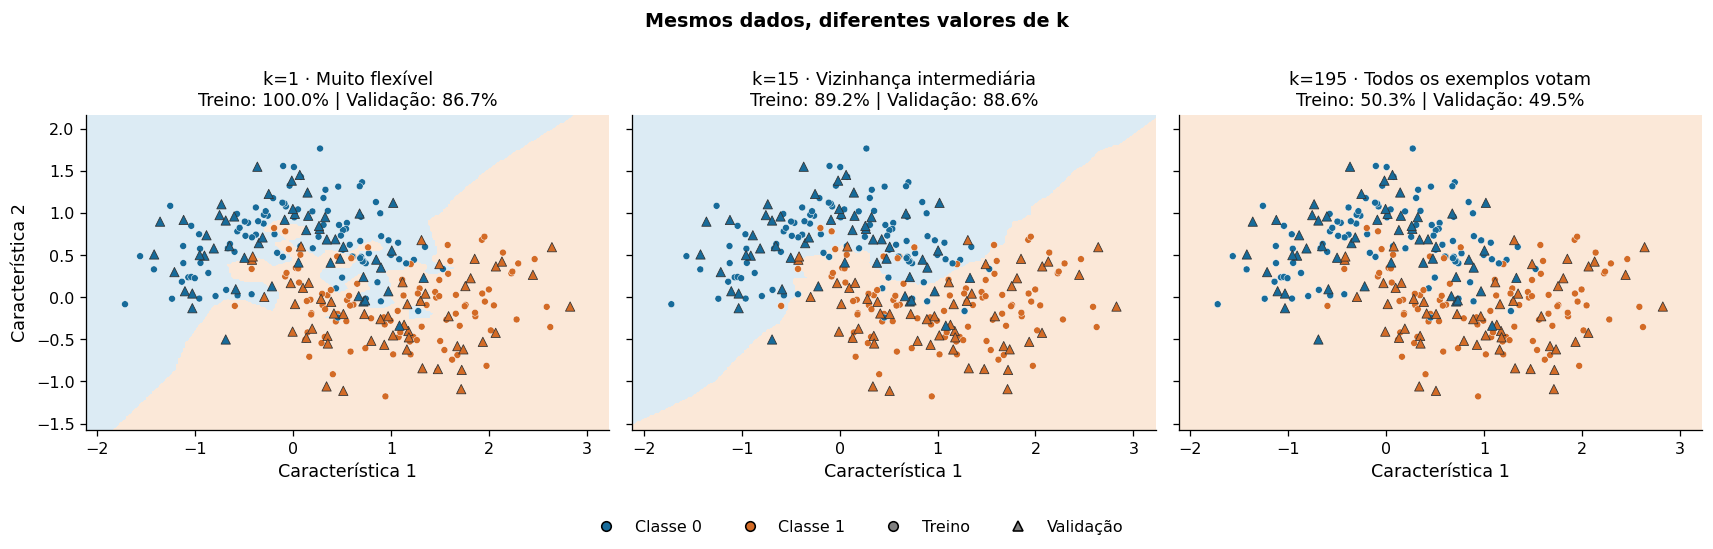

,Treino (%),Validação (%)
k,,
1,100.00,86.67
15,89.23,88.57
195,50.26,49.52


In [20]:
eixo_x = np.linspace(X_luas[:, 0].min() - 0.4, X_luas[:, 0].max() + 0.4, 240)
eixo_y = np.linspace(X_luas[:, 1].min() - 0.4, X_luas[:, 1].max() + 0.4, 200)
xx, yy = np.meshgrid(eixo_x, eixo_y)
grade = np.c_[xx.ravel(), yy.ravel()]
cores_fundo = ListedColormap(["#DCEBF4", "#FBE8D8"])
cores_pontos = ListedColormap([AZUL, LARANJA])
titulos = ["Muito flexível", "Vizinhança intermediária", "Todos os exemplos votam"]
resultados_visuais = []

fig, eixos = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
for ax, k, titulo in zip(eixos, ks_visuais, titulos):
    modelo = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    modelo.fit(X_luas_train, y_luas_train)
    regioes = modelo.predict(grade).reshape(xx.shape)
    treino = modelo.score(X_luas_train, y_luas_train)
    validacao = modelo.score(X_luas_val, y_luas_val)
    resultados_visuais.append({"k": k, "treino": treino, "validacao": validacao})
    ax.contourf(xx, yy, regioes, levels=[-0.5, 0.5, 1.5], cmap=cores_fundo)
    ax.scatter(X_luas_train[:, 0], X_luas_train[:, 1], c=y_luas_train,
               cmap=cores_pontos, vmin=0, vmax=1, s=19, edgecolors="white", linewidths=0.3)
    ax.scatter(X_luas_val[:, 0], X_luas_val[:, 1], c=y_luas_val,
               cmap=cores_pontos, vmin=0, vmax=1, s=34, marker="^", edgecolors="#333333", linewidths=0.5)
    ax.set_title(f"k={k} · {titulo}\nTreino: {treino:.1%} | Validação: {validacao:.1%}", fontsize=11)
    ax.set_xlabel("Característica 1")
eixos[0].set_ylabel("Característica 2")
legenda = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=AZUL, label="Classe 0"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=LARANJA, label="Classe 1"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="gray", label="Treino"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="gray", label="Validação"),
]
fig.legend(handles=legenda, loc="lower center", ncol=4, frameon=False)
fig.suptitle("Mesmos dados, diferentes valores de k", fontweight="bold", y=1.01)
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

tabela_visual = pd.DataFrame(resultados_visuais).set_index("k")
display((tabela_visual * 100).round(2).rename(columns={"treino": "Treino (%)", "validacao": "Validação (%)"}))

### 7.2. Ler os resultados com a turma

Com esta base e esta divisão, a execução de referência mostra aproximadamente:

| Configuração | Treino | Validação | O que observar |
|---|---:|---:|---|
| `k=1` | 100,0% | 86,7% | Regiões pequenas e irregulares; diferença maior entre os conjuntos |
| `k=15` | 89,2% | 88,6% | Perde acertos no treino, mas melhora a validação |
| `k=195` | 50,3% | 49,5% | Quase uma resposta única para todos; não acompanha as duas luas |

O primeiro modelo mostra **sinais de overfitting**: 100% no treino não se transfere para a validação. O terceiro é um exemplo claro de **underfitting**: simplificou tanto a decisão que perdeu o padrão. Entre os três, o intermediário generaliza melhor nesta divisão.

**A ideia central:** aceitar alguns erros no treino pode ser parte de construir um modelo melhor para dados novos.

**Perguntas para discussão:**
1. Qual modelo decora melhor os exemplos já vistos?
2. Qual teve o melhor resultado em exemplos não usados no ajuste?
3. Por que aumentar `k` indefinidamente não resolve o problema?

## 8. Voltar à base real e construir a curva de complexidade

Vamos repetir o treinamento com vários valores de `k` e registrar duas medidas: acurácia de treino e acurácia de validação. **O teste continua reservado.**

Começamos por `1` a `25`, como no material de referência. Incluímos também valores maiores para observar o que acontece quando a vizinhança se torna ampla demais.

**Antes de executar:** você espera que a melhor acurácia de validação coincida com a melhor acurácia de treino?

In [21]:
neighbors = np.unique(np.r_[np.arange(1, 26), 51, 101, 201, len(X_train)])
train_accuracies = {}
val_accuracies = {}

for neighbor in neighbors:
    knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=int(neighbor))
    )
    knn.fit(X_train, y_train)
    train_accuracies[int(neighbor)] = knn.score(X_train, y_train)
    val_accuracies[int(neighbor)] = knn.score(X_val, y_val)

resultados = pd.DataFrame({
    "k": neighbors,
    "acuracia_treino": list(train_accuracies.values()),
    "acuracia_validacao": list(val_accuracies.values()),
})
resultados["diferenca"] = resultados["acuracia_treino"] - resultados["acuracia_validacao"]
display(resultados.round(4))

,k,acuracia_treino,acuracia_validacao,diferenca
0,1,1.0000,0.9386,0.0614
1,2,0.9824,0.9474,0.0350
2,3,0.9765,0.9649,0.0116
3,4,0.9795,0.9649,0.0146
4,5,0.9736,0.9561,0.0175
5,6,0.9707,0.9737,-0.0030
6,7,0.9677,0.9561,0.0116
7,8,0.9765,0.9561,0.0204
8,9,0.9736,0.9474,0.0262
9,10,0.9677,0.9474,0.0204


### 8.1. Escolher usando a validação

**Regra definida para esta atividade:** escolher a maior acurácia de validação. Em caso de empate, escolher o **maior `k` entre os empatados**, favorecendo uma vizinhança menos sensível a um exemplo isolado. É um critério didático de desempate, não uma lei universal.

Não escolha pelo treino: isso favoreceria `k=1` mesmo que ele classificasse pior os exemplos de validação.

In [22]:
ranking = resultados.sort_values(
    by=["acuracia_validacao", "k"], ascending=[False, False]
)
melhor_k = int(ranking.iloc[0]["k"])
melhor_acuracia_val = float(ranking.iloc[0]["acuracia_validacao"])
print(f"k escolhido: {melhor_k}")
print(f"Acurácia de validação: {melhor_acuracia_val:.2%}")
display(ranking.head(5).round(4))

k escolhido: 6
Acurácia de validação: 97.37%


,k,acuracia_treino,acuracia_validacao,diferenca
5,6,0.9707,0.9737,-0.0030
3,4,0.9795,0.9649,0.0146
2,3,0.9765,0.9649,0.0116
7,8,0.9765,0.9561,0.0204
6,7,0.9677,0.9561,0.0116


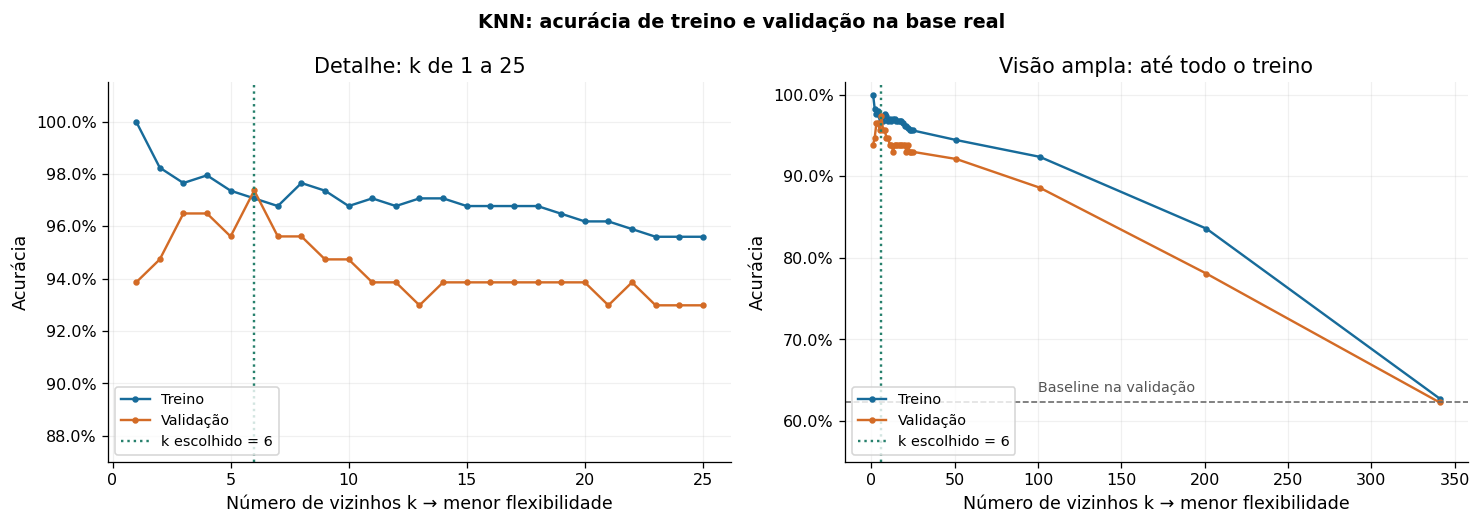

In [23]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, tabela, titulo in [
    (eixos[0], resultados[resultados["k"] <= 25], "Detalhe: k de 1 a 25"),
    (eixos[1], resultados, "Visão ampla: até todo o treino"),
]:
    ax.plot(tabela["k"], tabela["acuracia_treino"], "o-", color=AZUL, markersize=3, label="Treino")
    ax.plot(tabela["k"], tabela["acuracia_validacao"], "o-", color=LARANJA, markersize=3, label="Validação")
    ax.axvline(melhor_k, color=VERDE, linestyle=":", label=f"k escolhido = {melhor_k}")
    ax.set(title=titulo, xlabel="Número de vizinhos k → menor flexibilidade", ylabel="Acurácia")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(alpha=0.18)
    ax.legend(loc="lower left", fontsize=9)
eixos[0].set_ylim(0.87, 1.015)
eixos[1].set_ylim(0.55, 1.015)
eixos[1].axhline(acuracia_baseline, color="#666666", linestyle="--", linewidth=1)
eixos[1].text(100, acuracia_baseline + 0.013, "Baseline na validação", fontsize=9, color="#555555")
fig.suptitle("KNN: acurácia de treino e validação na base real", fontweight="bold")
fig.tight_layout()
plt.show()

### 8.2. Interpretar sem forçar uma história

1. **Olhe a validação:** onde estão os melhores resultados?
2. **Compare com o treino:** há uma diferença relevante entre as duas curvas?
3. **Observe o extremo de `k` grande:** as duas acurácias caem e se aproximam da baseline.
4. **Não espere uma curva perfeita:** pequenas oscilações são normais em uma amostra finita. A validação pode até ficar um pouco acima do treino pela composição dos conjuntos; isso, sozinho, não indica erro.

Na base real, `k=1` acerta o treino inteiro, mas algumas configurações intermediárias acertam mais na validação. Quando todos os exemplos votam, o modelo volta à resposta majoritária. Esses comportamentos conectam os números às regiões de decisão da demonstração anterior.

**Atenção aos eixos:** o primeiro painel amplia a faixa de acurácia para mostrar pequenas diferenças; o segundo inclui desempenhos mais baixos. Os valores e a escala estão identificados nos eixos.

O melhor `k` encontrado é o melhor **entre os candidatos e nesta divisão**. Outra divisão pode alterar o resultado. Em estudos mais completos, podemos usar validação cruzada para reduzir a dependência de uma única separação; ela fica como continuação da disciplina.

## 9. Avaliar a configuração final no teste reservado

Agora a escolha está encerrada. Vamos criar um modelo com `melhor_k`, ajustar novamente usando **treino + validação** (`X_dev`) e avaliar no teste.

É permitido aproveitar a validação no ajuste final porque não faremos mais escolhas com ela. A padronização também será recalculada apenas nesse conjunto de desenvolvimento. O teste permanece fora de todo ajuste.

**Regra da avaliação final:** depois de ver o teste, não volte a trocar `k` para melhorar essa nota. Se fizer isso, estará usando o teste para escolher o modelo.

In [24]:
modelo_final = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=melhor_k)
)
modelo_final.fit(X_dev, y_dev)
previsoes_test = modelo_final.predict(X_test)
acuracia_test = accuracy_score(y_test, previsoes_test)
acertos_test = int(np.sum(y_test.to_numpy() == previsoes_test))

baseline_final = DummyClassifier(strategy="most_frequent").fit(X_dev, y_dev)
print(f"Configuração final: k={melhor_k}")
print(f"Dados usados no ajuste final: {len(X_dev)} amostras")
print(f"Teste: {acertos_test}/{len(y_test)} acertos = {acuracia_test:.2%}")
print(f"Baseline no mesmo teste: {baseline_final.score(X_test, y_test):.2%}")

Configuração final: k=6
Dados usados no ajuste final: 455 amostras
Teste: 109/114 acertos = 95.61%
Baseline no mesmo teste: 63.16%


### 9.1. Em quais classes ocorreram os erros?

A matriz de confusão detalha as **mesmas previsões finais**, sem escolher outro modelo. Nas linhas está a classe real; nas colunas, a prevista. A diagonal reúne os acertos; fora dela estão os erros.

**Leia com a turma:** quantas amostras de cada classe foram confundidas com a outra?

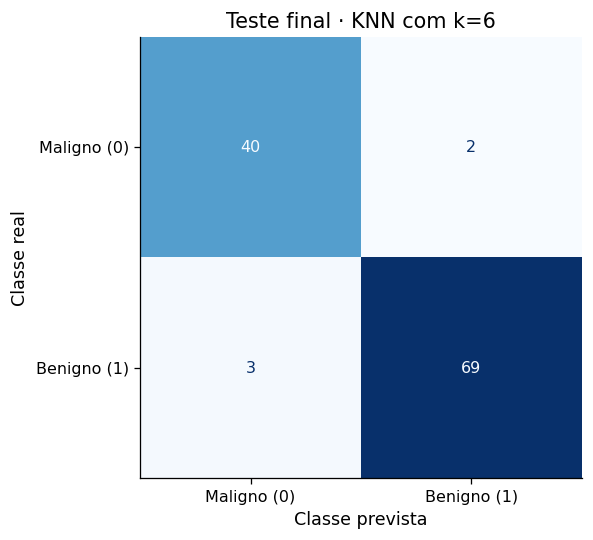

In [25]:
fig, ax = plt.subplots(figsize=(6.2, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_test, previsoes_test, labels=[0, 1],
    display_labels=["Maligno (0)", "Benigno (1)"],
    cmap="Blues", colorbar=False, ax=ax, values_format="d"
)
ax.set(title=f"Teste final · KNN com k={melhor_k}", xlabel="Classe prevista", ylabel="Classe real")
plt.tight_layout()
plt.show()

**Conclusão que os dados permitem:** temos uma estimativa do desempenho desta configuração em amostras reservadas da mesma base. O número não garante o mesmo resultado em qualquer população ou contexto.

## 10. Retomar as ideias antes da atividade

| Se você observar… | Pense em… | Ação possível |
|---|---|---|
| Treino e validação baixos | Underfitting ou características pouco informativas | No KNN, experimentar menor `k` e revisar as entradas |
| Treino muito alto e validação pior | Possível overfitting | No KNN, experimentar maior `k` e verificar a qualidade dos dados |
| Treino e validação bons e próximos | Indício de boa generalização | Confirmar a escolha no teste reservado |
| Acurácia alta, mas uma classe nunca é identificada | Limitação da acurácia isolada | Comparar com baseline e examinar os erros por classe |

**Evite estes erros:** incluir a resposta em `X`; padronizar toda a base antes da divisão; escolher `k` pelo teste; confundir 100% no treino com qualidade garantida; afirmar que um número específico de vizinhos é sempre ideal.

**Pergunta final oral:** por que o modelo com mais acertos no treino pode não ser o que devemos escolher?

## 11. Atividade para entregar até a próxima aula

**Aluno(a):** Ygor Farias de Melo 
**Turma:** OADSNM2C

Agora você aplicará o mesmo processo em outra **base real**, a **Wine**, com medidas químicas de vinhos de três classes. A tarefa é prever a classe, não a qualidade ou o preço. A base tem 178 amostras e 13 características e também acompanha o scikit-learn.

**Entrega individual:** este notebook, com as seis atividades abaixo resolvidas, os gráficos visíveis e as respostas escritas em Markdown. Nome sugerido: `Aula6_NomeSobrenome.ipynb`.

**Prazo:** até a próxima aula. **Valor sugerido:** 10 pontos. **Tempo estimado fora de aula:** 60–90 minutos.

Execute a célula de preparação. Use variáveis com prefixo `ex_` para não sobrescrever o experimento da aula. As células de resposta estão intencionalmente sem solução; os comentários não impedem a execução do notebook.

In [26]:
# Preparação fornecida para a atividade.
base_ex = load_wine(as_frame=True)
ex_X = base_ex.data.copy()
ex_y = base_ex.target.copy()
print("Base da atividade carregada:", ex_X.shape)

Base da atividade carregada: (178, 13)


### Exercício 1 · Conhecer a base (1,0 ponto)

Mostre as cinco primeiras linhas de `ex_X`, conte as amostras de cada classe e verifique valores ausentes. Explique, em duas ou três frases, o que representam `ex_X`, `ex_y` e por que o alvo não deve aparecer entre as entradas.

In [27]:
# Sua solução do exercício 1.
# Dicas: .head(), .value_counts() e .isna().sum().

# 1) Cinco primeiras linhas de ex_X
print("Cinco primeiras linhas de ex_X:")
display(ex_X.head())

# 2) Contagem de amostras por classe
print("\nAmostras por classe:")
print(ex_y.value_counts())

# (opcional) em proporção, útil para ver se há desbalanceamento
print("\nProporção por classe:")
print(ex_y.value_counts(normalize=True))

# 3) Valores ausentes
print("\nValores ausentes em ex_X (por coluna):")
print(ex_X.isna().sum())

print("\nValores ausentes em ex_y:")
print(ex_y.isna().sum())

Cinco primeiras linhas de ex_X:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



Amostras por classe:
1    71
0    59
2    48
Name: target, dtype: int64

Proporção por classe:
1    0.398876
0    0.331461
2    0.269663
Name: target, dtype: float64

Valores ausentes em ex_X (por coluna):
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Valores ausentes em ex_y:
0


**Resposta do exercício 1:** escreva aqui.

### Exercício 2 · Separar e construir uma referência (2,0 pontos)

1. Reserve 20% para teste (`ex_X_test`, `ex_y_test`) com `random_state=7` e estratificação.
2. Do conjunto de desenvolvimento (`ex_X_dev`, `ex_y_dev`), reserve 25% para validação, também com `random_state=7` e estratificação. Use `ex_X_train`, `ex_X_val`, `ex_y_train`, `ex_y_val`.
3. Mostre o tamanho de cada conjunto.
4. Treine uma baseline majoritária e um KNN com `k=5`, usando `StandardScaler` na pipeline. Informe a acurácia de treino e validação do KNN e a acurácia de validação da baseline.
5. Explique por que não calculou a acurácia de teste nesta etapa.

In [32]:
# Sua solução do exercício 2.
# Siga os dois passos de train_test_split da seção 4.
# Ajuste os modelos somente em ex_X_train, ex_y_train.


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# 1) Reserva 20% para teste (com estratificação)
ex_X_dev, ex_X_test, ex_y_dev, ex_y_test = train_test_split(
    ex_X, ex_y,
    test_size=0.20,
    random_state=7,
    stratify=ex_y
)

# 2) Do conjunto de desenvolvimento, reserva 25% para validação (com estratificação)
ex_X_train, ex_X_val, ex_y_train, ex_y_val = train_test_split(
    ex_X_dev, ex_y_dev,
    test_size=0.25,
    random_state=7,
    stratify=ex_y_dev
)

# 3) Tamanho de cada conjunto
print("Tamanho dos conjuntos:")
print(f"  Treino:    {len(ex_X_train)}")
print(f"  Validação: {len(ex_X_val)}")
print(f"  Teste:     {len(ex_X_test)}")

# 4) Baseline majoritária e KNN (k=5) com StandardScaler na pipeline
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(ex_X_train, ex_y_train)

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn.fit(ex_X_train, ex_y_train)

acc_knn_train = accuracy_score(ex_y_train, knn.predict(ex_X_train))
acc_knn_val = accuracy_score(ex_y_val, knn.predict(ex_X_val))
acc_base_val = accuracy_score(ex_y_val, baseline.predict(ex_X_val))

print("\nAcurácias:")
print(f"  KNN (k=5)  - treino:    {acc_knn_train:.4f}")
print(f"  KNN (k=5)  - validação: {acc_knn_val:.4f}")
print(f"  Baseline   - validação: {acc_base_val:.4f}")

Tamanho dos conjuntos:
  Treino:    106
  Validação: 36
  Teste:     36

Acurácias:
  KNN (k=5)  - treino:    0.9717
  KNN (k=5)  - validação: 0.9722
  Baseline   - validação: 0.3889


**Resposta do exercício 2:** escreva aqui.

### Exercício 3 · Construir a curva e escolher k (2,0 pontos)

Compare os valores **ímpares de 1 a 31, inclusive**, e também `k=len(ex_X_train)`.

- Crie uma tabela `ex_resultados` com `k`, `acuracia_treino` e `acuracia_validacao`.
- Faça um gráfico com as duas curvas, título, rótulos dos eixos e legenda.
- Escolha pela maior acurácia de validação. Em caso de empate, adote o maior `k` entre os empatados, como na aula. Guarde a escolha em `ex_melhor_k`.
- Não use o teste durante a comparação.

**Dica:** `np.arange(1, 32, 2)` gera os ímpares pedidos.

In [29]:
# Sua solução do exercício 3.
# Crie uma nova pipeline para cada valor de k.
# Você pode adaptar os dicionários e o loop da seção 8.

**k escolhido e justificativa:** escreva aqui.

### Exercício 4 · Explicar o comportamento (2,0 pontos)

Use os números do seu experimento para comparar `k=1`, `ex_melhor_k` e `k=len(ex_X_train)`.

1. Qual acerta mais no treino? Isso basta para escolher o modelo?
2. Onde há sinais de underfitting? Justifique com desempenho e comportamento.
3. Você observou sinais claros de overfitting em `k=1`? Pode responder **não**, se os resultados sustentarem isso. Explique.
4. Por que aumentar `k` geralmente torna a decisão menos sensível a um ponto isolado?

Responda em aproximadamente **6 a 10 linhas**. Não invente overfitting apenas porque o valor de `k` é pequeno.

In [30]:
# Opcional: exiba aqui somente as três linhas que sustentam sua análise.

**Resposta do exercício 4:** escreva aqui.

### Exercício 5 · Fazer a avaliação final (2,0 pontos)

Após fixar `ex_melhor_k`:
1. Ajuste uma nova pipeline em `ex_X_dev`, `ex_y_dev` (treino + validação).
2. Gere as previsões para `ex_X_test`.
3. Calcule a acurácia de teste por contagem de acertos e por `accuracy_score`.
4. Mostre a matriz de confusão com as três classes.
5. Escreva uma conclusão curta com o `k` escolhido, a acurácia e uma limitação do resultado. Não altere o modelo depois de ver o teste.

In [31]:
# Sua solução do exercício 5.
# Os dois cálculos de acurácia devem coincidir.

**Conclusão do exercício 5:** escreva aqui.

### Exercício 6 · Quando a acurácia engana (1,0 ponto)

Em uma base de 200 clientes, 180 permanecem e 20 cancelam. Um modelo prevê “permanece” para todos.

a) Qual é a acurácia? Mostre a conta.  
b) Quantos cancelamentos ele identifica?  
c) Esse resultado é suficiente para afirmar que o modelo é bom para identificar cancelamentos? Justifique em duas ou três frases.

**Resposta do exercício 6:** escreva aqui.

### Conferência antes de entregar

- [ ] Preenchi nome e turma.
- [ ] Reiniciei o ambiente e executei as células na ordem, sem erro.
- [ ] Mantive o teste fora da escolha de `k`.
- [ ] Entreguei tabela, curva de complexidade e matriz de confusão.
- [ ] Escrevi as interpretações com base nos meus resultados.
- [ ] Salvei o `.ipynb` com os resultados visíveis.

## Referências e origem do material

- Material-base fornecido pelo professor: **Avaliação de Modelo de Classificação**, exportado do Notion, 10 páginas. Foram mantidos o foco em KNN, acurácia, divisão dos dados, curva de complexidade e exercícios progressivos. Os exemplos foram reconstruídos com bases disponíveis e código completo.
- [scikit-learn: Breast Cancer Wisconsin (Diagnostic)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) · base real da aula.
- [scikit-learn: Wine](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) · base real da atividade.
- [scikit-learn: make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) · gerador da demonstração sintética.
- [scikit-learn: KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html).
- [scikit-learn: separação dos dados e avaliação](https://scikit-learn.org/stable/modules/cross_validation.html).
- [scikit-learn: prevenção de vazamento de dados](https://scikit-learn.org/stable/common_pitfalls.html).

As figuras deste notebook são geradas pelo próprio código; não dependem de imagens externas. Os valores numéricos exibidos são os da execução de referência. As versões utilizadas aparecem no início do notebook.